# 2D 이미지와 필터 구현

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 이미지 (3x3 행렬)
image_grey = np.array([
    [1, 1, 0],
    [0, 1, 0],
    [1, 0, 1]
])

# 필터 (2x2 행렬)
filter_grey = np.array([[1, 0], [0, 1]])

print("흑백 이미지:\n",image_grey)
print("필터:\n",filter_grey)

흑백 이미지:
 [[1 1 0]
 [0 1 0]
 [1 0 1]]
필터:
 [[1 0]
 [0 1]]


In [5]:
# 특징 맵 생성 함수
def apply_convolution(image_grey, filter_grey):

    size = filter_grey.shape[0]
    height, width = image_grey.shape
    result = np.zeros((height - size + 1, width - size + 1))
    print("result shape:", result.shape)
    for i in range(result.shape[0]):
        for j in range(result.shape[1]):
            print(f"i: {i}, j: {j}, image_grey[i:i+size, j:j+size]:\n{image_grey[i:i+size, j:j+size]}")
            print(f"i+size: {i+size}, j+size: {j+size}, filter_grey:\n{filter_grey}")
            # 이미지의 부분 행렬과 필터의 합성곱 수행
            result[i, j] = np.sum(image_grey[i:i+size, j:j+size] * filter_grey)
    return result

# 컨볼루션 적용
feature_map = apply_convolution(image_grey, filter_grey)

# 결과 출력
print('흑백 이미지:\n', image_grey)
print('필터:\n', filter_grey)
print('컨볼루션을 적용한 피처맵:\n', feature_map)

result shape: (2, 2)
i: 0, j: 0, image_grey[i:i+size, j:j+size]:
[[1 1]
 [0 1]]
i+size: 2, j+size: 2, filter_grey:
[[1 0]
 [0 1]]
i: 0, j: 1, image_grey[i:i+size, j:j+size]:
[[1 0]
 [1 0]]
i+size: 2, j+size: 3, filter_grey:
[[1 0]
 [0 1]]
i: 1, j: 0, image_grey[i:i+size, j:j+size]:
[[0 1]
 [1 0]]
i+size: 3, j+size: 2, filter_grey:
[[1 0]
 [0 1]]
i: 1, j: 1, image_grey[i:i+size, j:j+size]:
[[1 0]
 [0 1]]
i+size: 3, j+size: 3, filter_grey:
[[1 0]
 [0 1]]
흑백 이미지:
 [[1 1 0]
 [0 1 0]
 [1 0 1]]
필터:
 [[1 0]
 [0 1]]
컨볼루션을 적용한 피처맵:
 [[2. 1.]
 [0. 2.]]


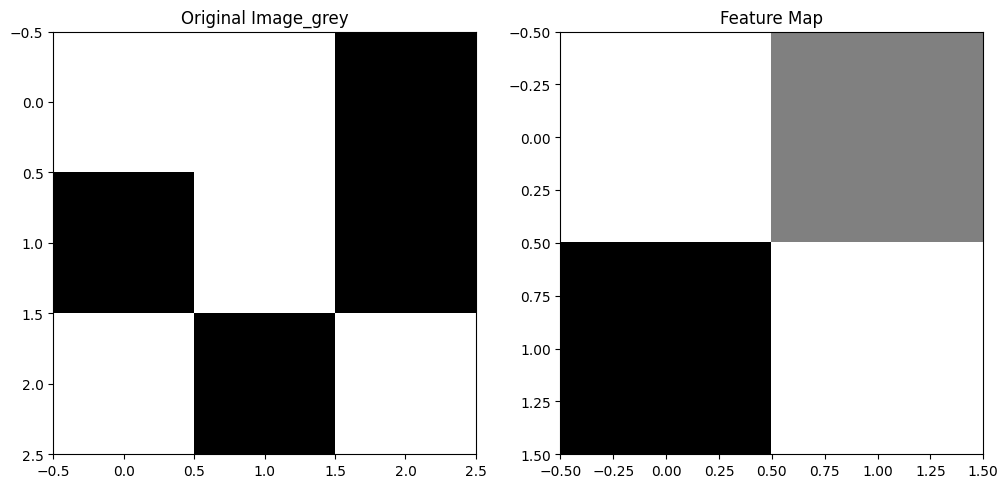

In [7]:
## 원본 이지미와 특징 맵 시각화
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title('Original Image_grey')
plt.imshow(image_grey, cmap='gray', interpolation='nearest')  # 이미지 시각화

plt.subplot(1, 2, 2)
plt.title('Feature Map')
plt.imshow(feature_map, cmap='gray', interpolation='nearest')  # 특징 맵 시각화

plt.show()

In [11]:
# 빨간색 채널
red_channel = np.array([
    [1, 2, 0, 2, 1],
    [0, 1, 1, 0, 0],
    [1, 0, 2, 0, 1],
    [0, 1, 1, 2, 0],
    [1, 0, 1, 0, 0]
])

# 녹색 채널
green_channel = np.array([
    [0, 1, 1, 0, 1],
    [0, 2, 1, 1, 0],
    [0, 0, 2, 0, 1],
    [0, 0, 1, 1, 0],
    [1, 0, 2, 2, 0]
])

# 파란색 채널
blue_channel = np.array([
    [1, 0, 2, 0, 1],
    [0, 0, 0, 1, 1],
    [1, 0, 2, 1, 2],
    [1, 0, 1, 0, 0],
    [0, 0, 1, 2, 0]
])

# 3차원 입력 배열
image_color = np.stack((red_channel, green_channel, blue_channel), axis=-1)

print("컬러 이미지 값:\n",image_color)
print("컬러 이미지의 형태:\n",image_color.shape)

컬러 이미지 값:
 [[[1 0 1]
  [2 1 0]
  [0 1 2]
  [2 0 0]
  [1 1 1]]

 [[0 0 0]
  [1 2 0]
  [1 1 0]
  [0 1 1]
  [0 0 1]]

 [[1 0 1]
  [0 0 0]
  [2 2 2]
  [0 0 1]
  [1 1 2]]

 [[0 0 1]
  [1 0 0]
  [1 1 1]
  [2 1 0]
  [0 0 0]]

 [[1 1 0]
  [0 0 0]
  [1 2 1]
  [0 2 2]
  [0 0 0]]]
컬러 이미지의 형태:
 (5, 5, 3)


In [12]:
# 필터의 각 채널
filter_red_channel = np.array([[1, 0], [0, 1]])
filter_green_channel = np.array([[1, 2], [0, 1]])
filter_blue_channel = np.array([[2, 0], [0, 0]])

# 3차원 필터 배열
filter_color = np.stack((filter_red_channel, filter_green_channel, filter_blue_channel), axis=-1)
#axis=-1 인자는 세 필터가 마지막 차원을 따라 쌓이게 함을 의미 
print("필터 값:\n",filter_color) 
print("필터의 형태:\n",filter_color.shape)

필터 값:
 [[[1 1 2]
  [0 2 0]]

 [[0 0 0]
  [1 1 0]]]
필터의 형태:
 (2, 2, 3)


## 3D 컨볼루션을 활용한 특징 맵 생성

In [13]:
# 컨볼루션 수행 함수
def apply_3d_convolution(image_color, filter_color):
    filter_size_x, filter_size_y, filter_depth = filter_color.shape
    image_color_height, image_color_width, image_color_depth = image_color.shape

    # 출력 이미지의 크기 결정 (스트라이드는 1로 가정)
    output_height = image_color_height - filter_size_x + 1
    output_width = image_color_width - filter_size_y + 1
    output = np.zeros((output_height, output_width))

    # 컨볼루션 연산 수행
    for x in range(output_height):
        for y in range(output_width):
            # 이미지와 필터의 각 지점에서의 원소별 곱셈 합
            output[x, y] = np.sum(image_color[x:x+filter_size_x, y:y+filter_size_y, :] * filter_color)

    return output


# 컨볼루션 적용
feature_map = apply_3d_convolution(image_color, filter_color)

# 결과 출력
print("Feature Map after Convolution:\n", feature_map)

Feature Map after Convolution:
 [[ 8.  7.  6.  4.]
 [ 4.  9.  4.  5.]
 [ 4.  6. 11.  4.]
 [ 2.  6.  8.  3.]]


In [14]:
#torch module 
import torch
import torch.nn as nn

In [15]:
print("입력 값:\n",image_color)
print("필터 값:\n",filter_color)

print("3D 이미지의 형태:\n",image_color.shape)
print("3D 필터의 형태:\n",filter_color.shape)

입력 값:
 [[[1 0 1]
  [2 1 0]
  [0 1 2]
  [2 0 0]
  [1 1 1]]

 [[0 0 0]
  [1 2 0]
  [1 1 0]
  [0 1 1]
  [0 0 1]]

 [[1 0 1]
  [0 0 0]
  [2 2 2]
  [0 0 1]
  [1 1 2]]

 [[0 0 1]
  [1 0 0]
  [1 1 1]
  [2 1 0]
  [0 0 0]]

 [[1 1 0]
  [0 0 0]
  [1 2 1]
  [0 2 2]
  [0 0 0]]]
필터 값:
 [[[1 1 2]
  [0 2 0]]

 [[0 0 0]
  [1 1 0]]]
3D 이미지의 형태:
 (5, 5, 3)
3D 필터의 형태:
 (2, 2, 3)


In [16]:
##### 이미지 텐서 변환 #####

input_tensor = torch.tensor(image_color, dtype=torch.float).unsqueeze(0)
#파이 토치의 신경망 모델은 배치 크기(한번에 처리할 이미지 수), 채널 수, 높이, 너비 형태의 입력을 기대한다. 
print("이미지 텐서에 차원 추가 :\n",input_tensor.shape)

input_tensor = input_tensor.permute(0, 3, 1, 2)
#permute는 텐서의 차원을 재배열 한다. 
#배치크기, 높이, 너비, 채널 수에서 배치 크기, 채널 수, 높이, 너비로 변경 
print("이미지 텐서의 차원을 재배열 :\n",input_tensor.shape)

##### 필터 텐서 변환 #####

filter_tensor = torch.tensor(filter_color, dtype=torch.float).unsqueeze(0).permute(0, 3, 1, 2)  
print("필터 텐서의 차원 추가 + 재배열 :\n",filter_tensor.shape)

이미지 텐서에 차원 추가 :
 torch.Size([1, 5, 5, 3])
이미지 텐서의 차원을 재배열 :
 torch.Size([1, 3, 5, 5])
필터 텐서의 차원 추가 + 재배열 :
 torch.Size([1, 3, 2, 2])


# 컨볼루션 레이어의 정의와 파라미터 설정



In [ ]:
conv_layer = nn.Conv2d(in_channels=3, out_channels=1, kernel_size=2)
#2D Convolution연산을 적용하는데 사용 
#in_channels=3, 입력 데이터의 채널수가 3임. RGB 3channel을 가지므로 3을 사용
#out_channels=1, 출력 데이터의 채널 수가 1임을 나타냄. 컨볼루션 레이어가 적용 된 후 생성되는 특징 맵의 수를 의미, 여기서는 하나의 특징맵을 생성하도록 설정
#kernel_size=2, convolution(kernel)의 크기가 ( 2X2)임을 의미, 필터가 각위치에서 2X2의 영역을 커버한다는 것
with torch.no_grad():
    conv_layer.weight = nn.Parameter(filter_tensor)
    #filter_tensor를 레이어의 가중치로 명시적으로 설정, nn.Parameter는 텐서를 모듈의 파라미터로 등록하여 자동으로 그라디언트를 계산할 수 있게 한다. 
    conv_layer.bias = nn.Parameter(torch.zeros(1)) 
    #convolution layer의 bias를 0으로 초기화, bias는 convolution 연산 후에 더해지는 상수 값으로, 여기서는 0으로 설정하여 bias가 없는 상태로 만듦.
    

In [21]:
#conv_layer를 사용하여 input_tensor에 합성곱 연산을 적용하고 그 결과를 output_tensor에 저장
output_tensor = conv_layer(input_tensor)

print('Output shape:', output_tensor.shape)
print("1 batch, 1 channel, 4 height, 4 width\n")
print('Output tensor:\n', output_tensor)

Output shape: torch.Size([1, 1, 4, 4])
1 batch, 1 channel, 4 height, 4 width

Output tensor:
 tensor([[[[ 8.,  7.,  6.,  4.],
          [ 4.,  9.,  4.,  5.],
          [ 4.,  6., 11.,  4.],
          [ 2.,  6.,  8.,  3.]]]], grad_fn=<ConvolutionBackward0>)
